In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

print("Libraries loaded successfully")

Libraries loaded successfully


In [10]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [11]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend for All 40 Schemes (2022-2026)"
)

fig.show()

In [12]:
import plotly.io as pio

pio.write_image(
    fig,
    "../reports/charts/nav_trend_analysis.png"
)

print("Chart saved")

Chart saved


In [13]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [14]:
import kaleido
print("Kaleido Working")

Kaleido Working


In [15]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


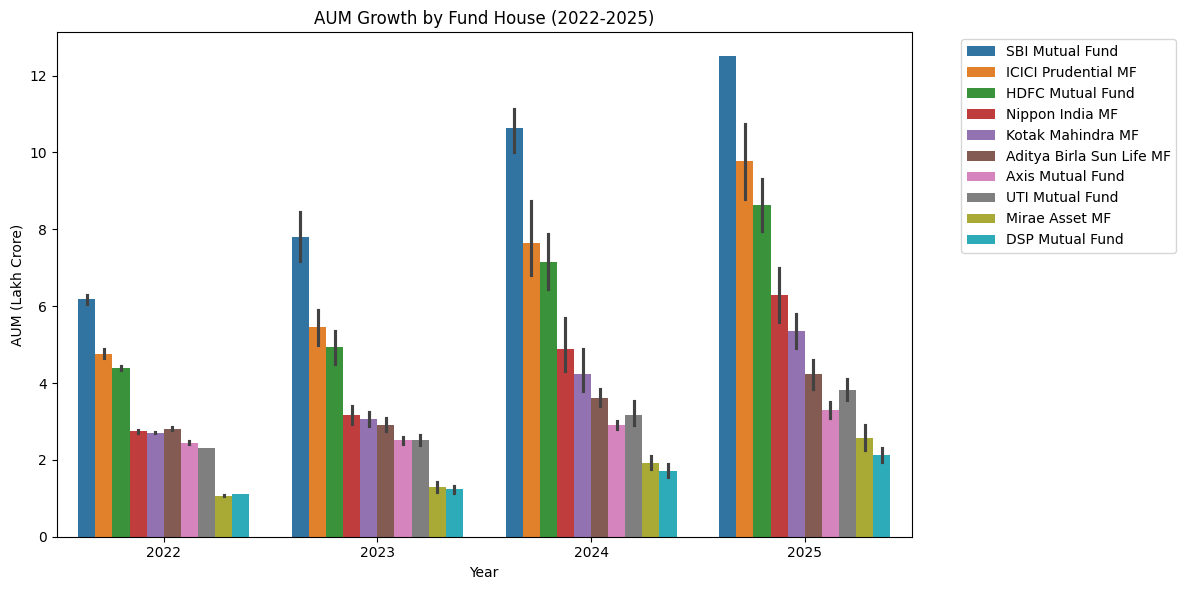

In [16]:
# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Create year column
aum["year"] = aum["date"].dt.year

# Plot chart
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.ylabel("AUM (Lakh Crore)")
plt.xlabel("Year")

plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()

plt.show()

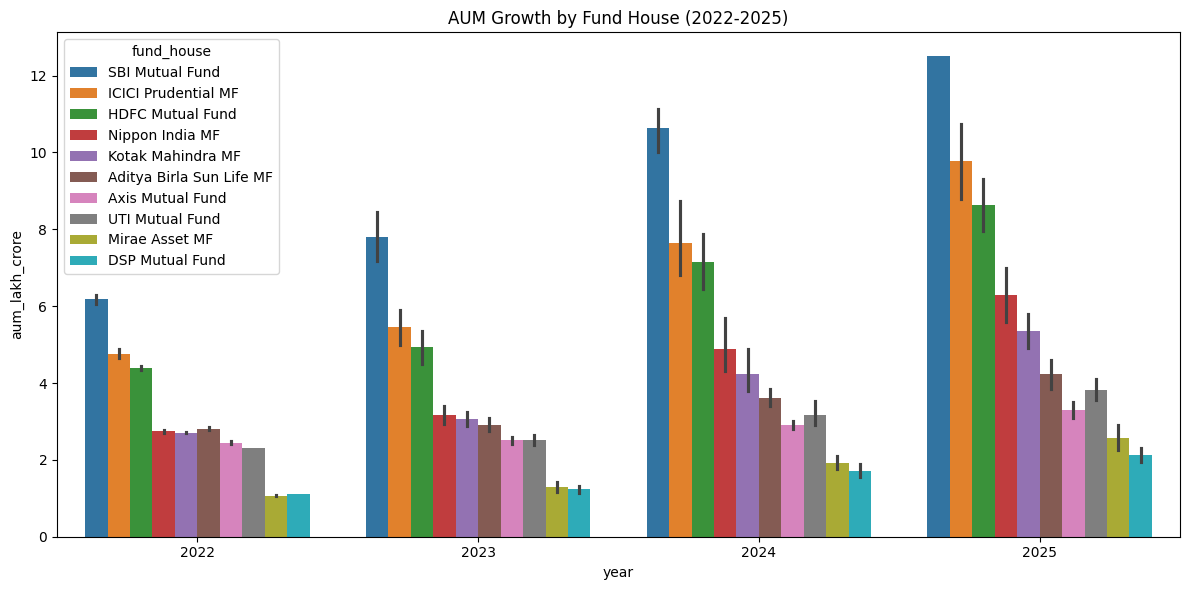

Chart Saved


In [17]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.tight_layout()

plt.savefig("../reports/charts/aum_growth_chart.png")

plt.show()

print("Chart Saved")

In [18]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [19]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)",
    markers=True
)

max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Highest SIP: ₹{max_row['sip_inflow_crore']} Cr",
    showarrow=True
)

fig.show()

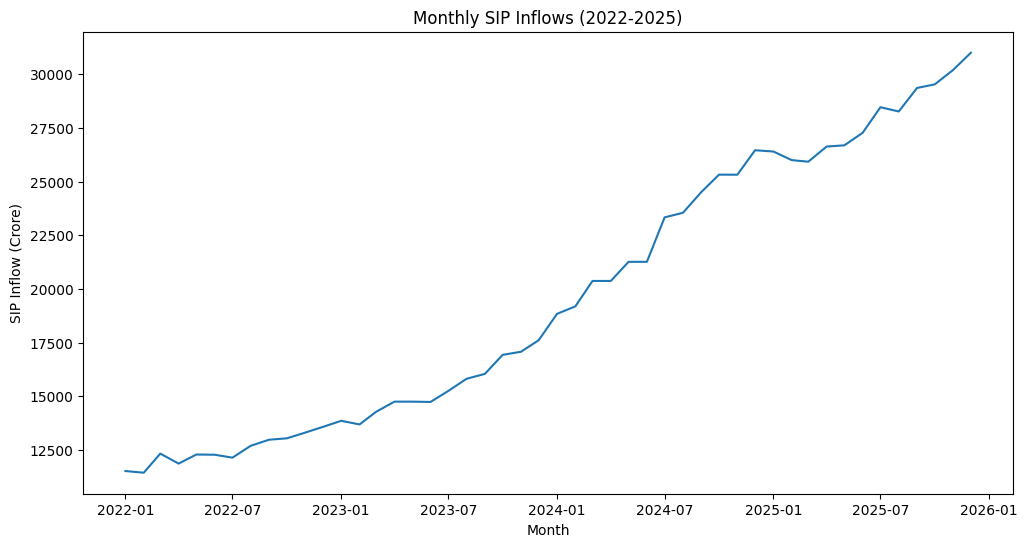

Chart Saved


In [20]:
plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.title("Monthly SIP Inflows (2022-2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.savefig("../reports/charts/sip_inflow_trend.png")

plt.show()

print("Chart Saved")

### Insight 1
SIP inflows showed a strong upward trend from 2022 to 2025, indicating growing retail participation in mutual funds.

In [21]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


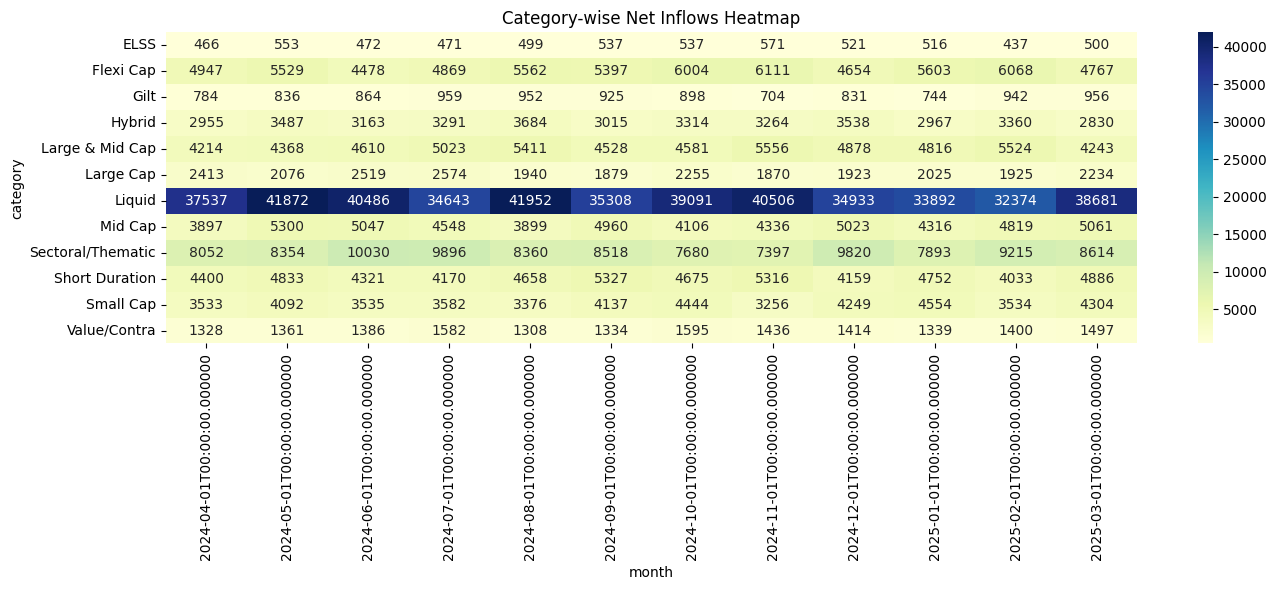

In [22]:
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Net Inflows Heatmap")

plt.tight_layout()

plt.show()

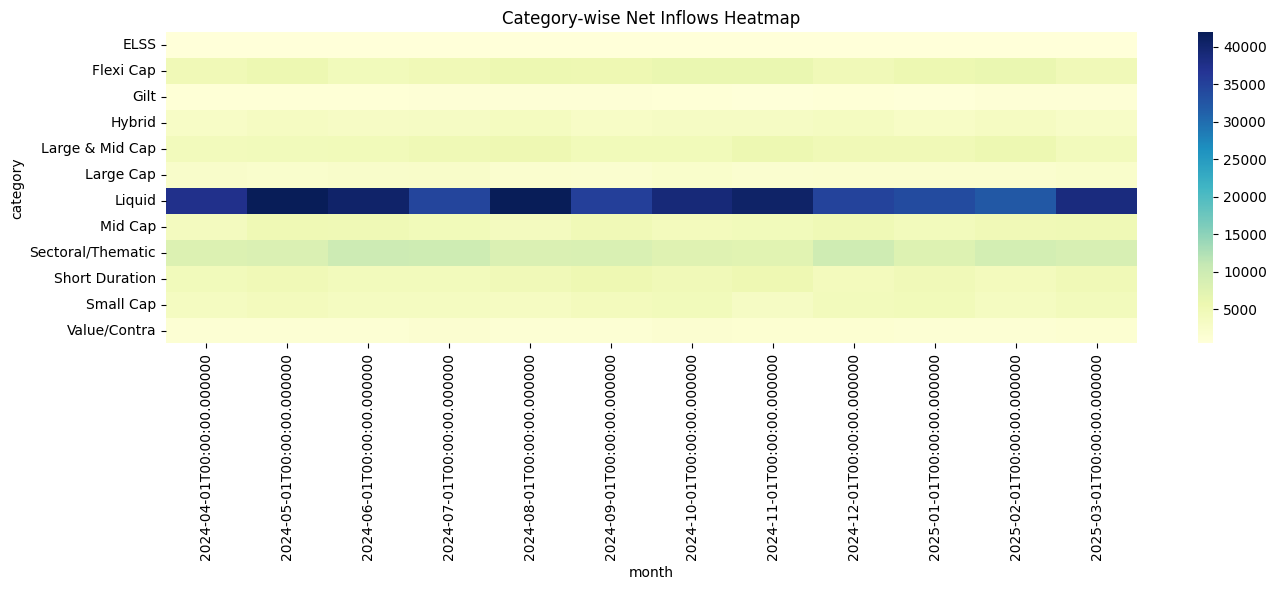

Chart Saved


In [23]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows Heatmap")

plt.tight_layout()

plt.savefig("../reports/charts/category_inflow_heatmap.png")

plt.show()

print("Chart Saved")

### Insight 2
Flexi Cap, Mid Cap, and Large & Mid Cap categories consistently attracted higher net inflows compared to other fund categories.

In [24]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


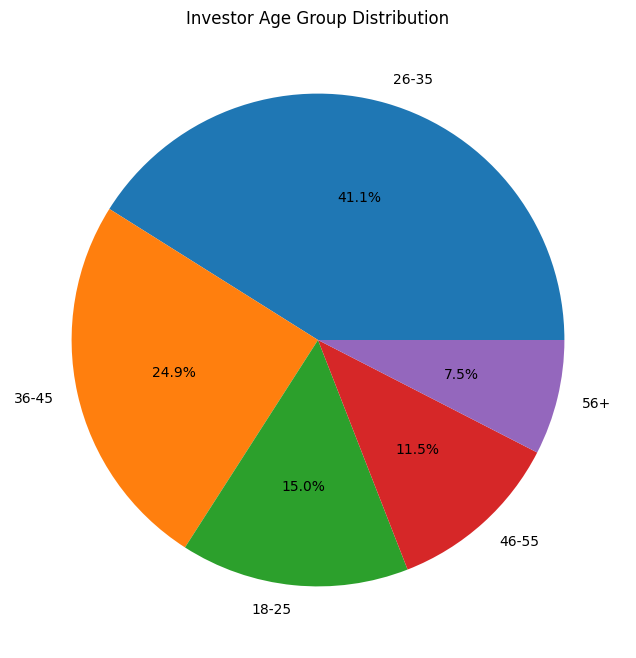

In [25]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

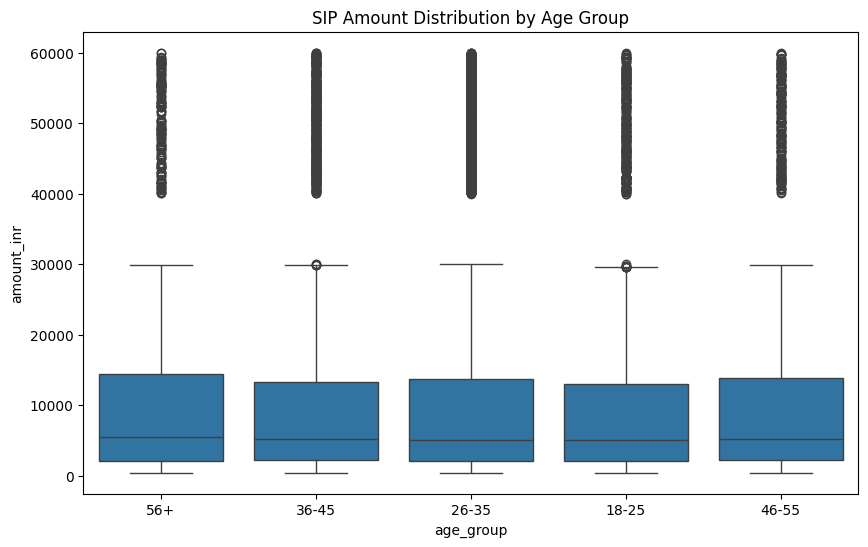

In [26]:
sip_only = transactions[
    transactions["transaction_type"] == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_only,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.show()

### Insight 3
The 26–35 and 36–45 age groups account for the largest share of mutual fund investors.

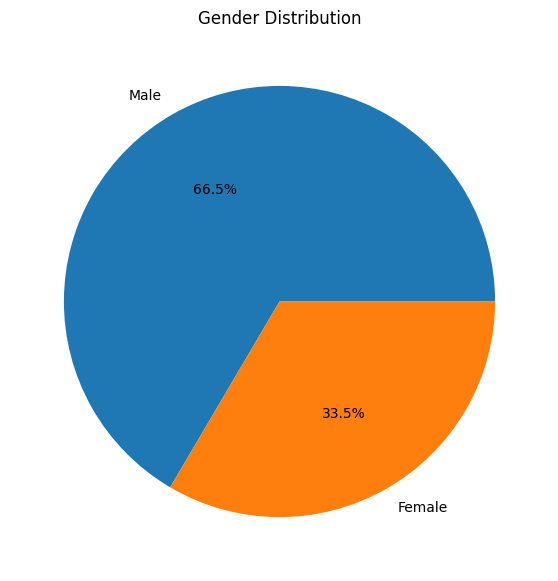

In [27]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

### Insight 4
SIP participation is widely distributed across states, with major urban states contributing the highest investment amounts.

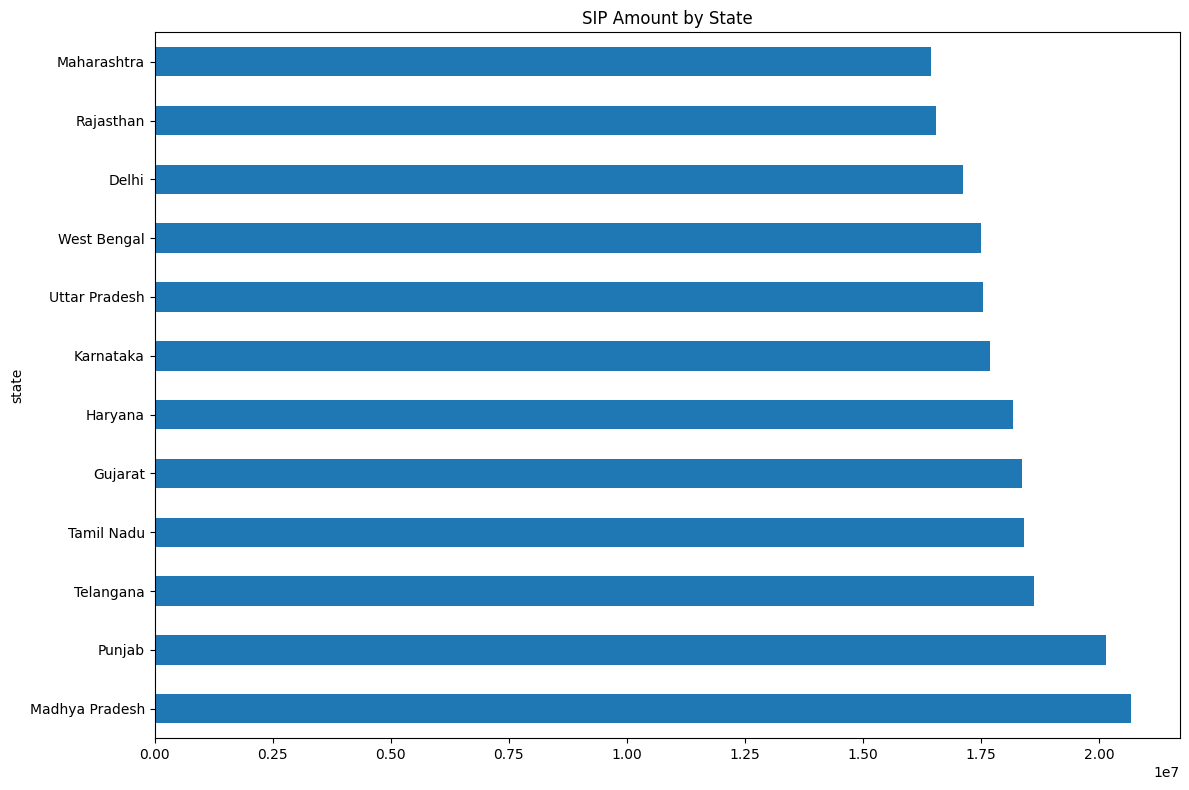

In [28]:
state_sip = (
    sip_only
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_sip.plot(kind="barh")

plt.title("SIP Amount by State")

plt.tight_layout()

plt.show()

### Insight 5
T30 cities contribute a larger share of mutual fund activity than B30 cities.

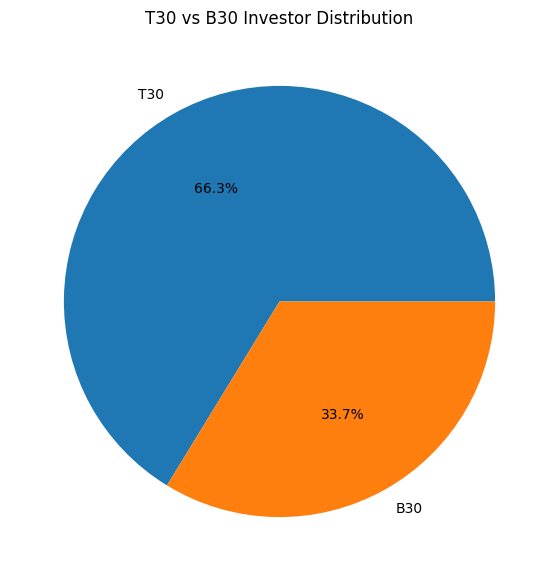

In [29]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

In [30]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


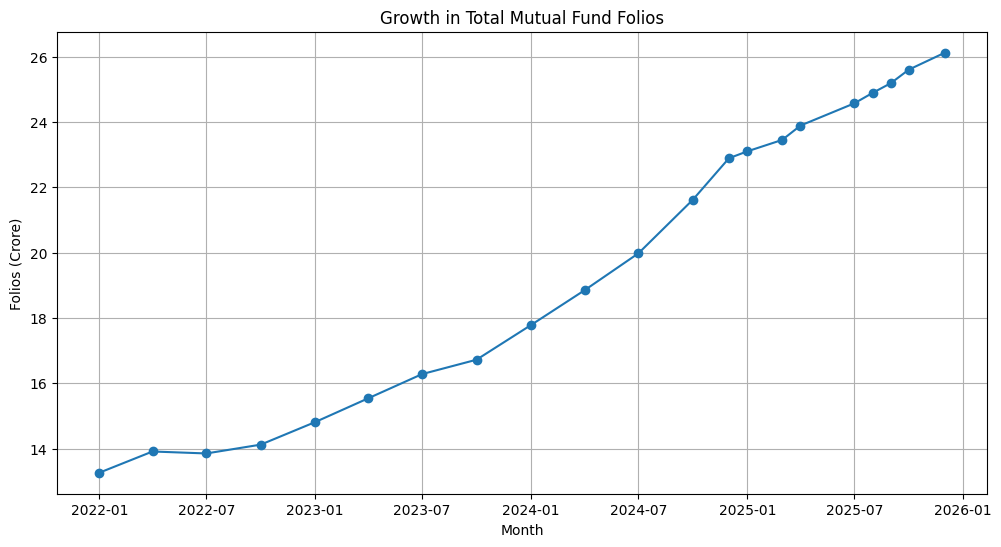

In [31]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Growth in Total Mutual Fund Folios")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.show()

### Insight 6
Total mutual fund folios nearly doubled from 13.26 crore in early 2022 to over 26 crore by 2025, reflecting rapid investor growth.

In [32]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


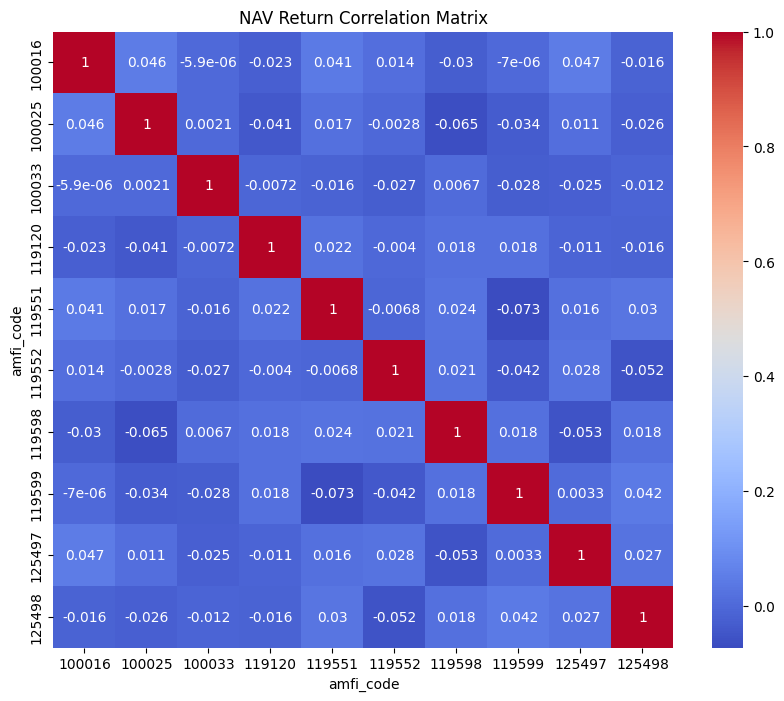

In [33]:
# Select first 10 funds
selected_funds = nav_history["amfi_code"].unique()[:10]

nav_subset = nav_history[
    nav_history["amfi_code"].isin(selected_funds)
]

pivot_nav = nav_subset.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.show()

### Insight 7
Most large-cap equity funds exhibit strong positive correlations, indicating similar market exposure and movement patterns.

In [34]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


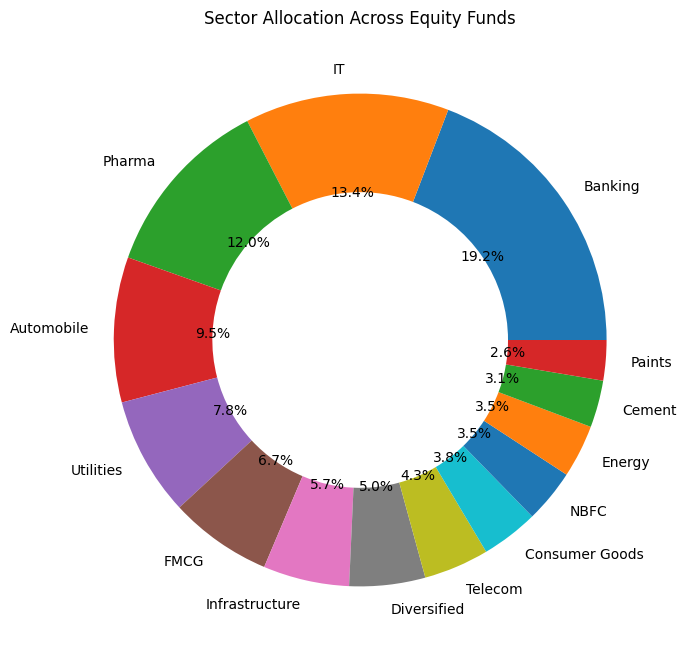

In [35]:
sector_data = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()


### Insight 8
Banking, Pharma, Utilities, and Diversified sectors represent a significant share of mutual fund portfolio allocations.

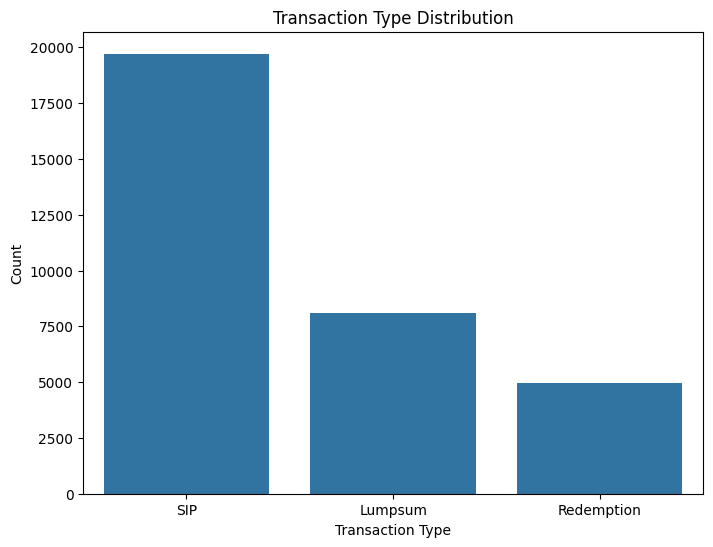

In [36]:
transaction_counts = transactions["transaction_type"].value_counts()

plt.figure(figsize=(8,6))

sns.barplot(
    x=transaction_counts.index,
    y=transaction_counts.values
)

plt.title("Transaction Type Distribution")

plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

### Insight 9
SIP transactions account for the majority of investor activity, highlighting the popularity of systematic investing.

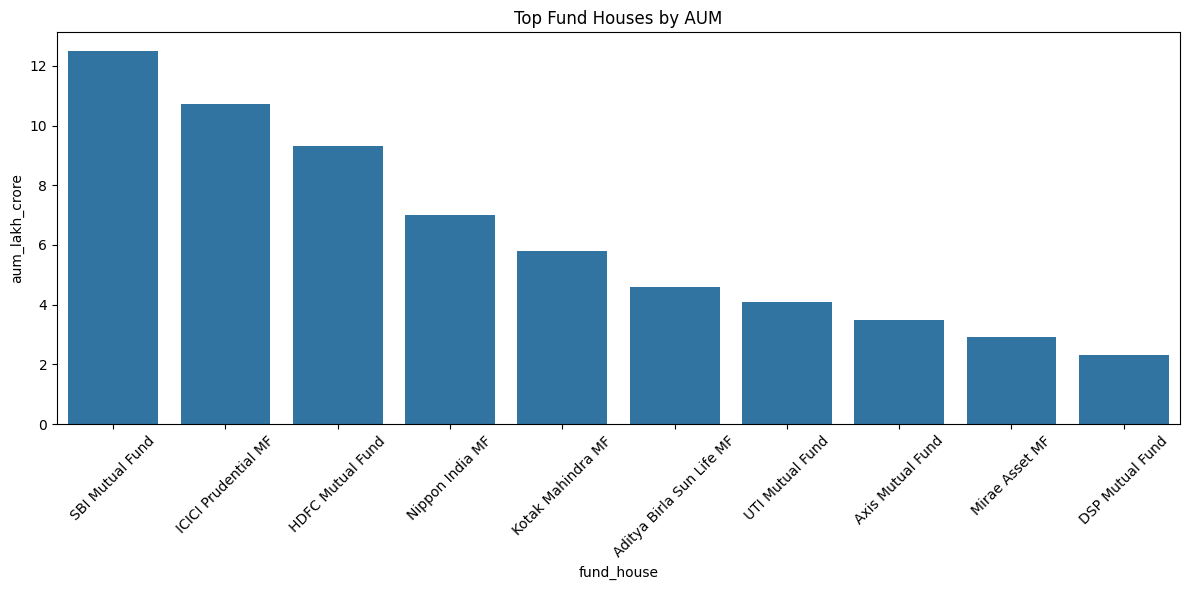

In [37]:
latest_date = aum["date"].max()

latest_aum = aum[
    aum["date"] == latest_date
]

top_aum = latest_aum.sort_values(
    "aum_lakh_crore",
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_aum,
    x="fund_house",
    y="aum_lakh_crore"
)

plt.xticks(rotation=45)

plt.title("Top Fund Houses by AUM")

plt.tight_layout()

plt.show()

### Insight 10
SBI Mutual Fund maintains the highest AUM among fund houses, demonstrating strong market leadership.

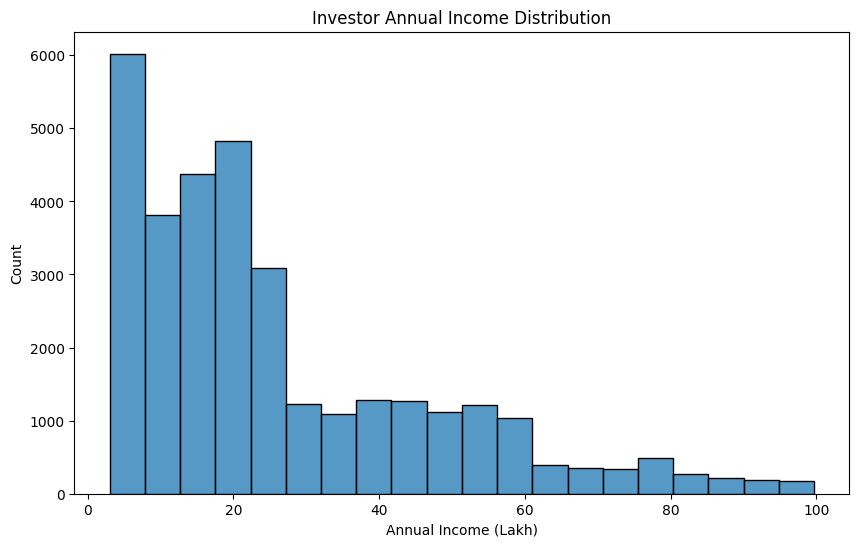

In [38]:
plt.figure(figsize=(10,6))

sns.histplot(
    transactions["annual_income_lakh"],
    bins=20
)

plt.title("Investor Annual Income Distribution")

plt.xlabel("Annual Income (Lakh)")
plt.ylabel("Count")

plt.show()